# Más allá de la precisión
## Sesgos, ética y control de calidad en Machine Learning

**Versión para participantes · Taller práctico · 120 minutos**

**Facilitador: Ing. Johannes Carofilis Veliz**

> **Caso:** una organización quiere usar un modelo que predice si el
> ingreso anual de una persona supera USD 50 000. Antes de aprobarlo,
> cada participante actuará como auditor responsable.

**Regla del taller:** una métrica describe un patrón; no explica por sí
sola su causa ni decide si un uso es justo.


### Antes de ejecutar código

La organización informa que el modelo tiene aproximadamente 85 % de
*accuracy*. Vota:

- [ ] Lo aprobaría.
- [ ] No lo aprobaría.
- [X] Necesito más información.

**Pregunta:** ¿qué cinco cosas necesitarías saber antes de permitir su
uso?

Una organización desea utilizar un modelo de Machine Learning para predecir si el ingreso anual de una persona supera los USD 50 000. Antes de aprobarlo, cada participante asumirá el rol de auditor y deberá evaluar su desempeño, sus errores, sus posibles sesgos y las condiciones bajo las cuales podría utilizarse.

**Tu respuesta (2 minutos):**


1.   El propósito real del modelo y qué decisiones tomarán con sus predicciones.
2.   El origen, antigüedad y población representada por los datos.
3.   Precision, recall, F1-score y matriz de confusión, no solo accuracy.
4.   El rendimiento y los errores separados por sexo, raza u otros grupos.
5.   Las consecuencias humanas de los falsos positivos y falsos negativos.





## Ruta de trabajo

1. Elegir y documentar el dataset.
2. Explorar calidad y representación.
3. Limpiar sin introducir fugas de información.
4. Elegir variables y entrenar una versión individual.
5. Registrar el experimento en Google Forms.
6. Crear una línea base y entrenar el modelo de referencia.
7. Interpretar errores globales.
8. Auditar resultados por grupos.
9. Comparar escenarios y umbrales.
10. Tomar una decisión con límites y controles.

### Tres tipos de problema que no debemos mezclar

| Capa | Pregunta | Ejemplo |
|---|---|---|
| Datos | ¿Qué población y realidad quedaron registradas? | Subrepresentación o etiqueta histórica desigual |
| Modelo | ¿Qué patrones aprende y cómo distribuye errores? | Recall menor para un grupo |
| Uso | ¿Qué decisión activa y quién soporta el error? | Una predicción usada para negar una oportunidad |


## Cómo usar este notebook si nunca has programado

Un notebook está formado por **celdas**:

- Las celdas de texto, como esta, explican y hacen preguntas.
- Las celdas de código tienen instrucciones para Python.
- El botón ▶ ejecuta una celda.
- El resultado aparece debajo; no necesitas copiarlo a otra parte.
- Si aparece `In [ ]`, todavía no se ejecutó. Si aparece un número,
  terminó de ejecutarse.

### Vocabulario mínimo de código

| Elemento | Significado sencillo |
|---|---|
| `import` | Traer una herramienta ya construida |
| `df` | Nombre dado a una tabla de datos |
| `=` | Guardar un resultado con un nombre; no es una comparación |
| `funcion(...)` | Pedir que una herramienta realice una tarea |
| `df["columna"]` | Seleccionar una columna de la tabla |
| `.head()` | Mostrar las primeras filas |
| `.fit(...)` | Aprender usando datos de entrenamiento |
| `.predict(...)` | Producir categorías con un modelo ya entrenado |
| `.predict_proba(...)` | Producir probabilidades |
| `# comentario` | Explicación para humanos; Python no la ejecuta |

### Lo que se espera de ti

No debes escribir un sistema desde cero ni memorizar sintaxis. Debes:

1. ejecutar las celdas en orden;
2. observar tablas y gráficos;
3. preguntar cuando un término no esté claro;
4. interpretar el resultado con tus propias palabras;
5. registrar evidencia en la hoja individual.

Si aparece un error, no significa que “no sabes programar”. Comprueba
primero si ejecutaste las celdas anteriores y pide apoyo al facilitador.


# 1. Elegir el dataset antes de descargarlo

Usaremos **Adult / Census Income**, creado a partir de datos del censo
de EE. UU. de 1994. Tiene 48 842 filas, 14 atributos y una etiqueta
binaria: ingreso `>50K` o `<=50K`.

**Fuente:** UCI Machine Learning Repository, DOI
[10.24432/C5XW20](https://doi.org/10.24432/C5XW20), licencia CC BY 4.0.
La copia se obtiene de OpenML con el identificador estable `1590`.

### Semáforo de idoneidad

Para cada pregunta marca 🟢 sí, 🟡 parcial/desconocido o 🔴 no.

| Criterio | Pregunta | Estado |
|---|---|---|
| Propósito | ¿La etiqueta representa realmente lo que necesitamos decidir? | ... |
| Población | ¿Lugar, periodo y personas coinciden con el uso? | ... |
| Cobertura | ¿Los grupos relevantes tienen suficiente representación? | ... |
| Calidad | ¿Conocemos faltantes, errores y cómo se midió? | ... |
| Legal/ético | ¿Licencia, privacidad y expectativas permiten el uso? | ... |
| Daño | ¿Podemos describir FP, FN, afectados y vías de apelación? | ... |
| Documentación | ¿Hay procedencia, diccionario y usos prohibidos? | ... |

**Usos no permitidos en este taller:** no interpretar ingreso como mérito,
potencial o confiabilidad; no usar este modelo para empleo, crédito,
seguros o acceso a servicios.


**Actividad (3 minutos):** escribe dos razones por las que este
dataset puede servir para aprender y dos por las que no debería
trasladarse directamente a una decisión actual.

**Pausa de auditoría 1:** registra en tu hoja individual el
propósito del modelo y los posibles riesgos.


# 2. Cargar y conocer los datos

Ejecuta las celdas en orden. La primera descarga puede tomar un minuto.
Si OpenML está temporalmente ocupado, vuelve a ejecutar la celda.


### Antes de ejecutar: preparar las herramientas

**Vocabulario:** `import` significa traer librerías, es decir, conjuntos de herramientas ya programadas. `pandas` trabaja con tablas; `scikit-learn` prepara, entrena y evalúa modelos.

**¿Qué hace?** Carga las funciones que utilizaremos y fija una semilla para obtener una división reproducible.

**¿Qué no hace?** Todavía no descarga datos, no entrena un modelo y no produce conclusiones.

**¿Qué debes observar?** La celda normalmente termina sin mostrar una tabla. Que no haya salida es correcto.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", context="notebook")


### Antes de ejecutar: descargar el dataset

**Vocabulario:** `fetch_openml` descarga datos; `data_id=1590` identifica una versión concreta; `df_raw` significa tabla original sin limpiar.

**¿Qué hace?** Descarga Adult, crea una copia y muestra cinco filas para reconocer sus columnas.

**¿Qué no hace?** Mostrar cinco filas no comprueba la calidad ni demuestra que el dataset sea representativo.

**¿Qué debes observar?** El número de filas y columnas, los nombres de las variables y la etiqueta `income`.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


In [ ]:
adult = fetch_openml(data_id=1590, as_frame=True)
df_raw = adult.frame.copy()

# En OpenML la etiqueta se llama "class"; la renombramos para leerla mejor.
if "class" in df_raw.columns:
    df_raw = df_raw.rename(columns={"class": "income"})

print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")
display(df_raw.head())


Filas: 48,842 | Columnas: 15


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


### Diccionario mínimo

- `age`, `education-num`, `hours-per-week`, `capital-gain/loss`:
  numéricas.
- `workclass`, `education`, `marital-status`, `occupation`,
  `relationship`, `native-country`: categóricas.
- `sex`, `race`: atributos sensibles disponibles en categorías
  históricas limitadas.
- `fnlwgt`: peso censal; no es una medición simple de la persona.
- `income`: etiqueta observada.

Que una columna esté disponible **no significa** que sea apropiada para
cualquier uso.


### Antes de ejecutar: hacer un inventario de columnas

**Vocabulario:** `dtype` es el tipo de dato; `NaN` representa ausencia; `nunique` cuenta valores distintos.

**¿Qué hace?** Resume para cada columna su tipo, cantidad de faltantes y cantidad de valores diferentes.

**¿Qué no hace?** No decide automáticamente qué columnas son buenas, sensibles o útiles.

**¿Qué debes observar?** Qué variables tienen faltantes y cuáles son numéricas o categóricas.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


In [ ]:
resumen_tipos = pd.DataFrame({
    "tipo": df_raw.dtypes.astype(str),
    "faltantes_detectados": df_raw.isna().sum(),
    "valores_unicos": df_raw.nunique(dropna=True)
}).sort_values("faltantes_detectados", ascending=False)
display(resumen_tipos)


,tipo,faltantes_detectados,valores_unicos
occupation,category,2809,14
workclass,category,2799,8
native-country,category,857,41
fnlwgt,int64,0,28523
education,category,0,16
education-num,int64,0,16
age,int64,0,74
marital-status,category,0,7
relationship,category,0,6
sex,category,0,2


# 3. Limpiar con decisiones explícitas

Haremos una limpieza mínima y trazable:

1. quitar espacios de categorías;
2. convertir `?` y ausencias a `NaN`;
3. normalizar la etiqueta a 0/1;
4. **no** eliminar supuestos duplicados sin identificador;
5. imputar y codificar dentro del pipeline, después de dividir.

Dos personas distintas pueden compartir todos estos atributos. Por eso
una fila repetida no prueba que sea un duplicado real.


### Antes de ejecutar: normalizar texto y faltantes

**Vocabulario:** Normalizar significa representar de la misma manera valores equivalentes. `NaN` es el marcador estándar de un dato ausente.

**¿Qué hace?** Quita espacios, convierte `?` en ausencia y cuenta faltantes y filas idénticas.

**¿Qué no hace?** No inventa los valores faltantes, no elimina filas y no prueba que una fila idéntica sea la misma persona.

**¿Qué debes observar?** Las tres columnas con faltantes y la cantidad de filas aparentemente repetidas.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


In [ ]:
df = df_raw.copy()
columnas_texto = df.select_dtypes(include=["object", "category", "string"]).columns

for columna in columnas_texto:
    serie = df[columna].astype("string").str.strip()
    serie = serie.mask(serie.eq("?"))
    df[columna] = serie.astype(object)
    df[columna] = df[columna].where(pd.notna(df[columna]), np.nan)

faltantes = df.isna().sum().sort_values(ascending=False)
print("Faltantes después de normalizar marcadores:")
display(faltantes[faltantes > 0].to_frame("n"))
print("Filas con atributos idénticos (no necesariamente personas duplicadas):",
      int(df.duplicated().sum()))


Faltantes después de normalizar marcadores:


,n
occupation,2809
workclass,2799
native-country,857


Filas con atributos idénticos (no necesariamente personas duplicadas): 52


### Antes de ejecutar: convertir la etiqueta y medir el desbalance

**Vocabulario:** La etiqueta es lo que queremos predecir. Codificar como `1` y `0` facilita el cálculo; clase positiva no significa persona mejor.

**¿Qué hace?** Convierte `>50K` en 1, `<=50K` en 0 y calcula cuántos ejemplos hay de cada clase.

**¿Qué no hace?** No cambia el ingreso de nadie ni corrige desigualdades históricas.

**¿Qué debes observar?** Qué clase es mayoritaria y por qué una regla que siempre elija esa clase podría parecer precisa.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


,n,proporcion
income,,
<=50K,37155,0.760718
>50K,11687,0.239282


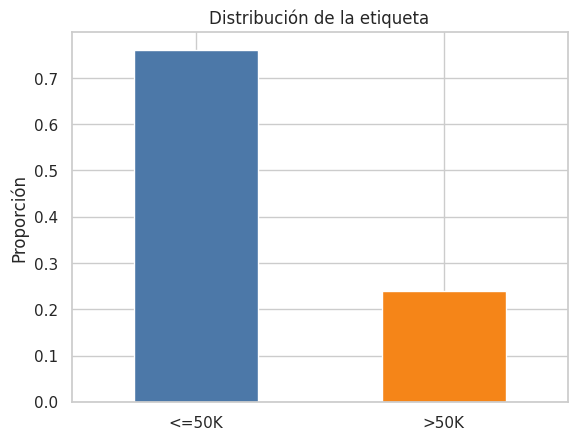

In [ ]:
# La etiqueta positiva es ingreso superior a 50K.
etiqueta_texto = df["income"].astype("string").str.replace(".", "", regex=False)
y = etiqueta_texto.eq(">50K").astype(int)

tabla_clase = (
    y.value_counts()
     .rename(index={0: "<=50K", 1: ">50K"})
     .to_frame("n")
)
tabla_clase["proporcion"] = tabla_clase["n"] / len(y)
display(tabla_clase)

ax = tabla_clase["proporcion"].plot.bar(color=["#4C78A8", "#F58518"])
ax.set(title="Distribución de la etiqueta", xlabel="", ylabel="Proporción")
ax.tick_params(axis="x", rotation=0)
plt.show()


### Antes de ejecutar: comparar representación y el efecto de borrar faltantes

**Vocabulario:** `crosstab` crea una tabla cruzada; `dropna` eliminaría filas que tienen al menos un faltante; puntos porcentuales comparan proporciones.

**¿Qué hace?** Compara la etiqueta por `sex` y simula cuánto cambiaría la composición si elimináramos filas incompletas.

**¿Qué no hace?** No demuestra causalidad, no afirma que un grupo sea homogéneo y no ejecuta realmente la eliminación sobre la tabla usada.

**¿Qué debes observar?** La diferencia de prevalencia, el tamaño de cada grupo y las 3 620 filas que se perderían.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


In [ ]:
representacion = pd.crosstab(
    df["sex"], etiqueta_texto, normalize="index"
).round(3)
representacion["n_grupo"] = df["sex"].value_counts()
display(representacion)

# ¿Qué cambiaría si borráramos toda fila con algún faltante?
antes = df["sex"].value_counts(normalize=True).rename("antes")
despues = df.dropna()["sex"].value_counts(normalize=True).rename("tras_dropna")
comparacion_dropna = pd.concat([antes, despues], axis=1)
comparacion_dropna["cambio_pp"] = (
    100 * (comparacion_dropna["tras_dropna"] - comparacion_dropna["antes"])
)
display(comparacion_dropna.round(3))
print(f"Filas que eliminaría dropna(): {len(df) - len(df.dropna()):,}")


income,<=50K,>50K,n_grupo
sex,,,
Female,0.891,0.109,16192
Male,0.696,0.304,32650


,antes,tras_dropna,cambio_pp
sex,,,
Male,0.668,0.675,0.657
Female,0.332,0.325,-0.657


Filas que eliminaría dropna(): 3,620


**Pregunta de interpretación:** ¿la diferencia observada por `sex`
demuestra que el sexo causa el nivel de ingreso? ¿Qué otras
explicaciones o datos faltan?

**Tu respuesta:** ...


# 4. Dividir antes de aprender transformaciones

Reservaremos 25 % para prueba y mantendremos la proporción de la etiqueta
mediante `stratify=y`. Excluimos `fnlwgt` del modelo educativo porque es
un peso censal cuya función requeriría un tratamiento específico.

Conservamos `sex` por separado para auditar ambos modelos, incluso cuando
no se usa para entrenar.


### Antes de ejecutar: separar entrenamiento y prueba

**Vocabulario:** Entrenamiento es la parte con la que el modelo aprende; prueba es la parte reservada para comprobarlo; `stratify` conserva la proporción de clases.

**¿Qué hace?** Reserva 25 % de las filas para prueba y guarda `sex` por separado para poder auditar.

**¿Qué no hace?** No entrena todavía y no garantiza que la prueba represente otra época, país o población.

**¿Qué debes observar?** El tamaño de ambos conjuntos y que la proporción positiva sea cercana a 0.239 en los dos.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


In [ ]:
columnas_modelo = [c for c in df.columns if c not in ["income", "fnlwgt"]]
X = df[columnas_modelo].copy()
atributo_sensible = df["sex"].copy()

X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, atributo_sensible,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape)
print("Proporción positiva train/test:",
      round(y_train.mean(), 3), round(y_test.mean(), 3))


Entrenamiento: (36631, 13) | Prueba: (12211, 13)
Proporción positiva train/test: 0.239 0.239


### Antes de ejecutar: definir el pipeline de preparación

**Vocabulario:** Un pipeline es una secuencia de pasos. Imputar completa faltantes con una regla; one-hot convierte categorías en columnas; escalar pone numéricas en escalas comparables.

**¿Qué hace?** Define una receta reutilizable que preparará los datos y entrenará una regresión logística.

**¿Qué no hace?** Definir la receta no la ejecuta. La imputación no recupera el valor verdadero y one-hot no elimina sesgos.

**¿Qué debes observar?** No aparecerá una tabla: esta celda solamente crea la función `crear_pipeline`.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


In [ ]:
def crear_pipeline(X_referencia, class_weight=None):
    numericas = X_referencia.select_dtypes(include="number").columns.tolist()
    categoricas = [c for c in X_referencia.columns if c not in numericas]

    pipe_num = Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("escalar", StandardScaler())
    ])
    pipe_cat = Pipeline([
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    preparacion = ColumnTransformer([
        ("num", pipe_num, numericas),
        ("cat", pipe_cat, categoricas)
    ])
    return Pipeline([
        ("preparacion", preparacion),
        ("modelo", LogisticRegression(
            max_iter=1000,
            solver="liblinear",
            class_weight=class_weight,
            random_state=RANDOM_STATE
        ))
    ])


### Antes de ejecutar: preparar funciones de evaluación

**Vocabulario:** Una función reúne instrucciones que reutilizaremos. Soporte es la cantidad de registros detrás de una métrica.

**¿Qué hace?** Define una receta para calcular métricas globales y otra para repetirlas por grupo.

**¿Qué no hace?** Todavía no evalúa ningún modelo y una métrica por grupo no explica la causa de una diferencia.

**¿Qué debes observar?** No aparecerán resultados: las funciones quedan preparadas para las rondas siguientes.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


In [ ]:
def resumen_global(y_true, y_pred, probabilidades=None):
    resultado = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tasa_seleccion": np.mean(y_pred)
    }
    if probabilidades is not None:
        resultado["roc_auc"] = roc_auc_score(y_true, probabilidades)
    return resultado


def metricas_por_grupo(y_true, y_pred, grupos):
    evaluacion = pd.DataFrame({
        "y_true": np.asarray(y_true, dtype=int),
        "y_pred": np.asarray(y_pred, dtype=int),
        "grupo": np.asarray(grupos)
    }).dropna(subset=["grupo"])

    filas = []
    for nombre, parte in evaluacion.groupby("grupo", observed=True):
        yt = parte["y_true"]
        yp = parte["y_pred"]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        filas.append({
            "grupo": nombre,
            "soporte": len(parte),
            "positivos_reales": int(yt.sum()),
            "accuracy": accuracy_score(yt, yp),
            "precision": precision_score(yt, yp, zero_division=0),
            "recall": recall_score(yt, yp, zero_division=0),
            "fpr": fp / (fp + tn) if (fp + tn) else np.nan,
            "fnr": fn / (fn + tp) if (fn + tp) else np.nan,
            "tasa_seleccion": yp.mean()
        })
    return pd.DataFrame(filas).set_index("grupo").sort_index()


# 5. Ronda preliminar: construye tu propia versión del modelo

Antes de conocer el modelo de referencia, selecciona las variables que
consideres más adecuadas para predecir si el ingreso anual registrado
supera USD 50 000.

Tu objetivo no es únicamente obtener la mayor accuracy. Considera
también:

- simplicidad;
- facilidad de interpretación;
- calidad y disponibilidad;
- atributos sensibles;
- posibles proxies;
- consecuencias de los errores.

Todos utilizaremos el mismo dataset, la misma división, el mismo
algoritmo, los mismos hiperparámetros y el mismo pipeline. **La única
diferencia será la selección de variables.**

### Variables disponibles

| Variable | Descripción breve |
|---|---|
| `age` | Edad registrada |
| `workclass` | Tipo de empleo |
| `education` | Nivel educativo como categoría |
| `education-num` | Nivel educativo codificado numéricamente |
| `marital-status` | Estado civil registrado |
| `occupation` | Ocupación |
| `relationship` | Relación familiar registrada |
| `race` | Categoría racial histórica y sensible |
| `sex` | Categoría sexual histórica y sensible |
| `capital-gain` | Ganancia de capital registrada |
| `capital-loss` | Pérdida de capital registrada |
| `hours-per-week` | Horas de trabajo semanales |
| `native-country` | País de origen registrado |

`income` es la etiqueta y no puede seleccionarse como entrada.
`fnlwgt` se excluye del ejercicio porque es un peso censal que requeriría
un tratamiento especializado.


### Antes de ejecutar: elegir variables

**Vocabulario:** Seleccionar variables significa decidir qué columnas recibirá el modelo. El código de participante identifica tu experimento sin depender de tu nombre.

**¿Qué hace?** Permite agregar o quitar variables y comprueba automáticamente que la lista sea válida.

**¿Qué no hace?** No determina si la selección es ética, no encuentra una combinación perfecta y no entrena todavía.

**¿Qué debes observar?** Tu lista final, el número de variables y los avisos sobre `sex` y `race`.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


In [ ]:
# Cambia P001 por el código que te indique el facilitador.
codigo_participante = "P001"

# Agrega o elimina nombres, conservando comillas y comas.
variables_participante = [
    "workclass",
    "education-num",
    "occupation",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
]

def validar_variables(seleccion, disponibles):
    errores = []

    if not isinstance(seleccion, list):
        errores.append(
            "variables_participante debe ser una lista entre corchetes."
        )
        seleccion = []

    if not seleccion:
        errores.append("Debes seleccionar al menos una variable.")

    no_texto = [v for v in seleccion if not isinstance(v, str)]
    if no_texto:
        errores.append("Todos los nombres deben escribirse entre comillas.")

    solo_texto = [v for v in seleccion if isinstance(v, str)]
    repetidas = sorted({
        v for v in solo_texto if solo_texto.count(v) > 1
    })
    if repetidas:
        errores.append(
            "Elimina variables repetidas: " + ", ".join(repetidas)
        )

    if "income" in solo_texto:
        errores.append(
            "No incluyas income: es la etiqueta que queremos predecir."
        )

    desconocidas = sorted(
        set(solo_texto) - set(disponibles) - {"income"}
    )
    if desconocidas:
        errores.append(
            "Estas variables no existen o no están disponibles: "
            + ", ".join(desconocidas)
        )

    if not isinstance(codigo_participante, str) or not codigo_participante.strip():
        errores.append("Escribe un código de participante no vacío.")

    if errores:
        raise ValueError(
            "Corrige la selección antes de continuar:\n- "
            + "\n- ".join(errores)
        )
    return solo_texto


variables_participante = validar_variables(
    variables_participante, X_train.columns.tolist()
)

print("Código:", codigo_participante)
print("Variables seleccionadas:", ", ".join(variables_participante))
print("Número de variables:", len(variables_participante))
print("Incluye sex:", "Sí" if "sex" in variables_participante else "No")
print("Incluye race:", "Sí" if "race" in variables_participante else "No")


Código: P001
Variables seleccionadas: workclass, education-num, occupation, capital-gain, capital-loss, hours-per-week
Número de variables: 6
Incluye sex: No
Incluye race: No


### Justifica tu selección antes de conocer los resultados

- **¿Qué variables seleccionaste?** ...
- **¿Por qué las seleccionaste?** ...
- **¿Qué variables decidiste excluir?** ...
- **¿Incluiste `sex` o `race`? ¿Por qué?** ...
- **¿Crees que el modelo será confiable?** ...
- **¿Qué riesgo podría tener tu selección?** ...

Escribe primero tu hipótesis. No cambies la justificación después de
ver las métricas; podrás reflexionar sobre ella al final.


### Antes de ejecutar: entrenar tu modelo individual

**Vocabulario:** Tu modelo usa exactamente la selección que acabas de validar. FP y FN son falsos positivos y falsos negativos.

**¿Qué hace?** Entrena una regresión logística, calcula métricas globales, matriz de confusión y métricas por `sex`.

**¿Qué no hace?** No convierte tu selección en correcta, no demuestra discriminación y no modifica los modelos de referencia.

**¿Qué debes observar?** Accuracy, precision, recall, F1, FP, FN, brechas y grupo con menor recall.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


Métricas globales de tu modelo:


,modelo_participante
accuracy,0.818
balanced_accuracy,0.670
precision,0.726
recall,0.387
f1,0.505
tasa_seleccion,0.128
roc_auc,0.824


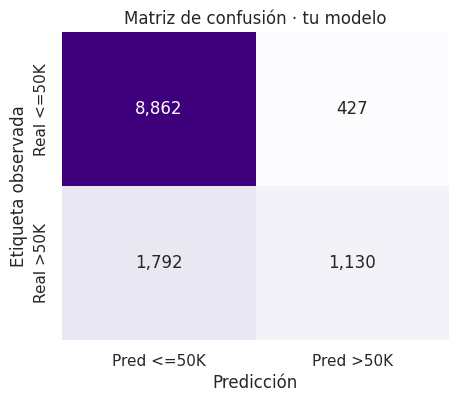

{'TN': 8862, 'FP': 427, 'FN': 1792, 'TP': 1130}
Métricas por grupo:


,soporte,positivos_reales,accuracy,precision,recall,fpr,fnr,tasa_seleccion
grupo,,,,,,,,
Female,4024,453,0.897,0.567,0.375,0.036,0.625,0.075
Male,8187,2469,0.779,0.764,0.389,0.052,0.611,0.154


Brecha recall: 0.014
Brecha FPR: 0.016
Grupo con menor recall: Female


In [ ]:
X_train_participante = X_train[variables_participante]
X_test_participante = X_test[variables_participante]

modelo_participante = crear_pipeline(X_train_participante)
modelo_participante.fit(X_train_participante, y_train)

predicciones_participante = modelo_participante.predict(
    X_test_participante
)
probabilidades_participante = modelo_participante.predict_proba(
    X_test_participante
)[:, 1]

metricas_participante = resumen_global(
    y_test, predicciones_participante, probabilidades_participante
)
matriz_participante = confusion_matrix(
    y_test, predicciones_participante, labels=[0, 1]
)
tn_part, fp_part, fn_part, tp_part = matriz_participante.ravel()

tabla_grupo_participante = metricas_por_grupo(
    y_test, predicciones_participante, A_test
)
brecha_recall_participante = (
    tabla_grupo_participante["recall"].max()
    - tabla_grupo_participante["recall"].min()
)
brecha_fpr_participante = (
    tabla_grupo_participante["fpr"].max()
    - tabla_grupo_participante["fpr"].min()
)
grupo_menor_recall_participante = (
    tabla_grupo_participante["recall"].idxmin()
)

print("Métricas globales de tu modelo:")
display(
    pd.Series(metricas_participante, name="modelo_participante")
    .to_frame()
    .round(3)
)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    matriz_participante,
    annot=True,
    fmt=",d",
    cmap="Purples",
    cbar=False,
    ax=ax,
    xticklabels=["Pred <=50K", "Pred >50K"],
    yticklabels=["Real <=50K", "Real >50K"]
)
ax.set_title("Matriz de confusión · tu modelo")
ax.set_xlabel("Predicción")
ax.set_ylabel("Etiqueta observada")
plt.show()

print({
    "TN": int(tn_part),
    "FP": int(fp_part),
    "FN": int(fn_part),
    "TP": int(tp_part)
})
print("Métricas por grupo:")
display(tabla_grupo_participante.round(3))
print("Brecha recall:", round(brecha_recall_participante, 3))
print("Brecha FPR:", round(brecha_fpr_participante, 3))
print("Grupo con menor recall:", grupo_menor_recall_participante)


## Registra tu experimento

Abre el formulario:

### [Google Forms — registrar resultados](https://forms.gle/dN6EsQnnCu93wURh6)

El notebook no envía datos automáticamente. La siguiente celda prepara
un resumen para copiar. Revisa los valores antes de enviarlos.

El formulario solicita iniciar sesión con Google. Si todavía no has
iniciado sesión, hazlo con la cuenta autorizada por la organización.

**Formato común:** copia accuracy, precision, recall, F1 y brechas como
decimales entre 0 y 1 usando punto (`0.8007`); copia FP, FN y número de
variables como enteros.


In [ ]:
resumen_forms_participante = {
    "Código del participante": codigo_participante.strip(),
    "Variables seleccionadas": ", ".join(variables_participante),
    "Número de variables": len(variables_participante),
    "Incluyó sex": "Sí" if "sex" in variables_participante else "No",
    "Incluyó race": "Sí" if "race" in variables_participante else "No",
    "Accuracy": round(metricas_participante["accuracy"], 4),
    "Precision": round(metricas_participante["precision"], 4),
    "Recall": round(metricas_participante["recall"], 4),
    "F1-score": round(metricas_participante["f1"], 4),
    "Verdaderos positivos": int(tp_part),
    "Verdaderos negativos": int(tn_part),
    "Falsos positivos": int(fp_part),
    "Falsos negativos": int(fn_part),
    "Diferencia de recall": round(brecha_recall_participante, 4),
    "Diferencia de FPR": round(brecha_fpr_participante, 4),
    "Grupo con menor recall": grupo_menor_recall_participante
}

for campo, valor in resumen_forms_participante.items():
    print(f"{campo}: {valor}")


Código del participante: P001
Variables seleccionadas: workclass, education-num, occupation, capital-gain, capital-loss, hours-per-week
Número de variables: 6
Incluyó sex: No
Incluyó race: No
Accuracy: 0.8183
Precision: 0.7258
Recall: 0.3867
F1-score: 0.5046
Verdaderos positivos: 1130
Verdaderos negativos: 8862
Falsos positivos: 427
Falsos negativos: 1792
Diferencia de recall: 0.0135
Diferencia de FPR: 0.0155
Grupo con menor recall: Female


### Detente aquí

1. Copia los valores de la celda anterior al
   [formulario](https://forms.gle/dN6EsQnnCu93wURh6).
2. Revisa que el código y las variables sean correctos.
3. Envía una sola respuesta.
4. No continúes hasta que el facilitador lo indique.

Los resultados se compararán colectivamente. El objetivo no es declarar
un ganador, sino observar cómo distintas decisiones de selección
producen diferentes niveles de rendimiento, errores, simplicidad y
riesgo.

Compararemos:

- mayor accuracy y mayor recall;
- menor brecha entre grupos;
- menor número de variables;
- frecuencia de selección de variables sensibles;
- relación entre cantidad de variables y rendimiento.


# 6. Modelo de referencia: línea base y dos escenarios

- **Línea base:** siempre predice la clase mayoritaria.
- **Escenario A:** usa `sex` entre los atributos.
- **Escenario B:** excluye `sex`, pero lo conserva para auditar.

Antes de ejecutar: ¿cuál crees que tendrá mayor accuracy? ¿cuál tendrá
menor brecha? Escribe tu hipótesis.


### Antes de ejecutar: entrenar tres referencias

**Vocabulario:** `fit` significa aprender parámetros; `predict` genera clases; `predict_proba` genera probabilidades. Una línea base es una regla simple de comparación.

**¿Qué hace?** Crea una línea base, un modelo con `sex` y otro sin `sex`, usando solamente entrenamiento para aprender.

**¿Qué no hace?** No decide cuál es justo, no demuestra causalidad y el modelo sin `sex` todavía puede usar variables proxy.

**¿Qué debes observar?** La frase “Modelos entrenados”. Los resultados se calculan en la siguiente celda.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


In [ ]:
# Línea base: todo se predice como 0 (<=50K).
pred_base = np.zeros(len(y_test), dtype=int)

modelo_con_sex = crear_pipeline(X_train)
modelo_con_sex.fit(X_train, y_train)
pred_con_sex = modelo_con_sex.predict(X_test)
proba_con_sex = modelo_con_sex.predict_proba(X_test)[:, 1]

X_train_sin = X_train.drop(columns=["sex"])
X_test_sin = X_test.drop(columns=["sex"])
modelo_sin_sex = crear_pipeline(X_train_sin)
modelo_sin_sex.fit(X_train_sin, y_train)
pred_sin_sex = modelo_sin_sex.predict(X_test_sin)
proba_sin_sex = modelo_sin_sex.predict_proba(X_test_sin)[:, 1]

print("Modelos entrenados.")


Modelos entrenados.


### Antes de ejecutar: calcular métricas globales

**Vocabulario:** Accuracy cuenta todos los aciertos; precision evalúa predicciones positivas; recall evalúa positivos reales; F1-score es la media armónica de precision y recall; ROC-AUC significa área bajo la curva ROC y mide ordenamiento.

**¿Qué hace?** Calcula varias métricas sobre datos de prueba para comparar los tres escenarios.

**¿Qué no hace?** Una tabla global no indica cómo se distribuyen errores entre grupos ni si el uso es ético.

**¿Qué debes observar?** Por qué la línea base tiene accuracy cercana a 0.761 pero recall igual a 0.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


### ¿Qué porcentaje es bueno?

No existe un corte universal. Un resultado es suficiente solo si se
compara con:

1. una línea base;
2. el costo de FP y FN;
3. el propósito y nivel de riesgo;
4. resultados por grupos;
5. incertidumbre y datos externos.

| Métrica | Dirección matemática deseable | Traducción del límite |
|---|---|---|
| Accuracy, precision, recall, F1, balanced accuracy, ROC-AUC | Más alto suele ser mejor | 1 significa desempeño perfecto en esa definición |
| FPR, FNR y brechas | Más bajo suele ser mejor | 0 significa ausencia de ese error o diferencia, no justicia garantizada |

Ejemplos con la referencia:

- Accuracy `0.852` significa 85.2 % de aciertos y **14.8 % de errores**.
- Precision `0.743` significa que aproximadamente **25.7 % de las
  predicciones positivas no coincidieron** con la etiqueta.
- Recall `0.585` significa que se detectó 58.5 % de los positivos y
  **se perdió 41.5 %**.
- F1 `0.654` resume un equilibrio intermedio; no es una nota de
  aprobación.
- ROC-AUC `0.904` indica buen ordenamiento relativo, pero no garantiza
  un umbral adecuado, calibración o equidad.

En una demostración educativa podemos describir un valor como alto,
medio o bajo **respecto a otra versión**. Para aprobar un uso real se
necesitan requisitos definidos antes de entrenar. En decisiones de alto
impacto, incluso un porcentaje de error aparentemente pequeño puede
afectar a muchas personas.


In [ ]:
globales = pd.DataFrame({
    "Línea base": resumen_global(y_test, pred_base),
    "Con sex": resumen_global(y_test, pred_con_sex, proba_con_sex),
    "Sin sex": resumen_global(y_test, pred_sin_sex, proba_sin_sex)
}).T
display(globales.round(3))


,accuracy,balanced_accuracy,precision,recall,f1,tasa_seleccion,roc_auc
Línea base,0.761,0.500,0.000,0.000,0.000,0.000,NaN
Con sex,0.852,0.762,0.740,0.589,0.656,0.190,0.904
Sin sex,0.852,0.761,0.743,0.585,0.654,0.188,0.904


**Actividad:** completa.

- La línea base puede tener accuracy aparentemente alta porque ...
- No elegiría un modelo solo por accuracy porque ...
- Para este caso, un falso negativo significa ...

**Pausa de auditoría 2:** anota accuracy, precision, recall y F1 del
modelo sin `sex`.


### Antes de ejecutar: leer la matriz de confusión

**Vocabulario:** TN y TP son aciertos; FP y FN son errores. “Falso” significa que la predicción no coincide con la etiqueta disponible.

**¿Qué hace?** Cuenta exactamente los cuatro tipos de resultado del modelo sin `sex` y los muestra como mapa de calor.

**¿Qué no hace?** No establece cuál error es moralmente peor; eso depende de la decisión que active el modelo.

**¿Qué debes observar?** Dónde están los falsos positivos y los falsos negativos y qué significarían en un escenario concreto.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


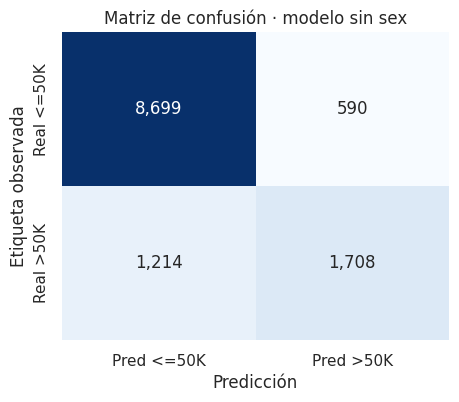

{'TN': 8699, 'FP': 590, 'FN': 1214, 'TP': 1708}


In [ ]:
matriz = confusion_matrix(y_test, pred_sin_sex, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    matriz, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
    xticklabels=["Pred <=50K", "Pred >50K"],
    yticklabels=["Real <=50K", "Real >50K"]
)
ax.set_title("Matriz de confusión · modelo sin sex")
ax.set_xlabel("Predicción")
ax.set_ylabel("Etiqueta observada")
plt.show()

tn, fp, fn, tp = matriz.ravel()
print({"TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)})


# 7. Auditoría por grupos

Las métricas de grupo responden preguntas distintas:

- `tasa_seleccion`: ¿qué proporción recibe predicción positiva?
- `recall` / TPR (*True Positive Rate*): de los positivos reales,
  ¿cuántos se detectan?
- `fnr` (*False Negative Rate*): de los positivos reales, ¿cuántos
  se pierden?
- `fpr` (*False Positive Rate*): de los negativos reales, ¿cuántos
  se marcan positivos?
- `precision`: de las predicciones positivas, ¿cuántas coinciden?

Ninguna es “la métrica de justicia” universal. La relevancia depende del
propósito y de las consecuencias.


### Antes de ejecutar: recalcular métricas para cada grupo

**Vocabulario:** `groupby` separa temporalmente la tabla por categoría; soporte es la cantidad de registros; FPR y FNR son tasas de error.

**¿Qué hace?** Usa la función preparada para calcular las mismas métricas dentro de cada grupo con la columna `sex`.

**¿Qué no hace?** No explica por qué existe una diferencia y las categorías disponibles no representan toda la diversidad.

**¿Qué debes observar?** Recall, FPR, FNR, tasa de selección y soporte de cada grupo; no mires una sola columna.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


In [ ]:
tabla_grupo = metricas_por_grupo(y_test, pred_sin_sex, A_test)
display(tabla_grupo.round(3))


,soporte,positivos_reales,accuracy,precision,recall,fpr,fnr,tasa_seleccion
grupo,,,,,,,,
Female,4024,453,0.924,0.739,0.506,0.023,0.494,0.077
Male,8187,2469,0.817,0.744,0.599,0.089,0.401,0.243


### Antes de ejecutar: resumir diferencias con una brecha

**Vocabulario:** Una brecha es el valor máximo menos el mínimo. 0.094 equivale a 9.4 puntos porcentuales.

**¿Qué hace?** Resume la distancia entre grupos para recall y FPR.

**¿Qué no hace?** No muestra la dirección, no considera incertidumbre y una brecha cero no garantiza un buen sistema.

**¿Qué debes observar?** Después del número vuelve siempre a la tabla para identificar qué grupo tiene cada valor.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


In [ ]:
# Reto: reemplaza None con máximo menos mínimo.
brecha_recall = (0.599 - 0.506)
brecha_fpr = (0.089 - 0.023)
print("Brecha recall:", brecha_recall)
print("Brecha FPR:", brecha_fpr)


Brecha recall: 0.09299999999999997
Brecha FPR: 0.066


**Actividad central (4 minutos):**

1. ¿Qué grupo presenta menor recall?
2. ¿La accuracy global permitía verlo?
3. ¿Qué consecuencia tendría **si** la predicción asignara una
   oportunidad?
4. ¿Qué limitación tiene comparar solo estas dos categorías?

**Pausa de auditoría 3:** registra tu hallazgo principal, dos
evidencias numéricas y el grupo posiblemente afectado.


### Antes de ejecutar: comparar decisiones de diseño

**Vocabulario:** Un escenario es una versión del experimento. Una variable proxy puede conservar indirectamente información de un atributo eliminado.

**¿Qué hace?** Coloca juntos tu modelo, la línea base, el modelo con `sex` y el modelo sin `sex`.

**¿Qué no hace?** No convierte automáticamente el escenario con menor brecha en el mejor; también deben revisarse utilidad y consecuencias.

**¿Qué debes observar?** Que quitar `sex` cambia las cifras, pero no hace desaparecer todas las diferencias.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


In [ ]:
tablas_escenario = {
    "Modelo participante": tabla_grupo_participante,
    "Línea base": metricas_por_grupo(y_test, pred_base, A_test),
    "Con sex": metricas_por_grupo(y_test, pred_con_sex, A_test),
    "Sin sex": metricas_por_grupo(y_test, pred_sin_sex, A_test)
}

comparacion = []
for escenario, tabla in tablas_escenario.items():
    fila = resumen_global(
        y_test,
        {
            "Modelo participante": predicciones_participante,
            "Línea base": pred_base,
            "Con sex": pred_con_sex,
            "Sin sex": pred_sin_sex
        }[escenario]
    )
    fila.update({
        "escenario": escenario,
        "brecha_recall": tabla["recall"].max() - tabla["recall"].min(),
        "brecha_fpr": tabla["fpr"].max() - tabla["fpr"].min(),
        "brecha_seleccion": (
            tabla["tasa_seleccion"].max() -
            tabla["tasa_seleccion"].min()
        )
    })
    comparacion.append(fila)

comparacion_escenarios = pd.DataFrame(comparacion).set_index("escenario")
display(comparacion_escenarios.round(3))


,accuracy,balanced_accuracy,precision,recall,f1,tasa_seleccion,brecha_recall,brecha_fpr,brecha_seleccion
escenario,,,,,,,,,
Modelo participante,0.818,0.670,0.726,0.387,0.505,0.128,0.014,0.016,0.079
Línea base,0.761,0.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Con sex,0.852,0.762,0.740,0.589,0.656,0.190,0.120,0.071,0.174
Sin sex,0.852,0.761,0.743,0.585,0.654,0.188,0.094,0.066,0.166


> **Conclusión que debemos comprobar, no asumir:** quitar `sex` no
> garantiza que desaparezcan las brechas. La etiqueta histórica y otras
> variables pueden conservar información correlacionada o actuar como
> proxies. A la vez, incluir o excluir una variable sensible puede estar
> sujeto a requisitos normativos y necesita análisis contextual.

Observa además que la línea base obtiene brechas iguales a cero porque
niega la clase positiva a todo el mundo. **Paridad no implica utilidad ni
justicia:** una métrica de brecha siempre debe leerse junto con desempeño,
consecuencias y distribución de resultados.


## Extensión: auditar por raza

Los grupos pequeños producen estimaciones más inestables. Lee siempre
`soporte` y `positivos_reales`; no ordenes grupos como si una diferencia
mínima fuera una verdad precisa.


### Antes de ejecutar: observar otros grupos e intersecciones

**Vocabulario:** Intersección significa combinar categorías, por ejemplo `sex × race`. Un grupo pequeño tiene pocas observaciones y métricas más inestables.

**¿Qué hace?** Repite la auditoría por `race` y después por combinaciones de `sex` y `race`.

**¿Qué no hace?** No permite comparar identidades humanas completas ni sacar conclusiones fuertes de grupos con muy poco soporte.

**¿Qué debes observar?** Las columnas `soporte` y `positivos_reales` antes de comparar porcentajes.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


In [ ]:
tabla_raza = metricas_por_grupo(
    y_test, pred_sin_sex, X_test["race"]
).sort_values("soporte", ascending=False)
display(tabla_raza.round(3))

# Extensión opcional: intersección de dos categorías sensibles.
grupos_interseccion = (
    X_test["sex"].astype(str) + " × " + X_test["race"].astype(str)
)
tabla_interseccion = metricas_por_grupo(
    y_test, pred_sin_sex, grupos_interseccion
).sort_values("soporte", ascending=False)
display(tabla_interseccion.head(10).round(3))


,soporte,positivos_reales,accuracy,precision,recall,fpr,fnr,tasa_seleccion
grupo,,,,,,,,
White,10385,2639,0.846,0.747,0.595,0.069,0.405,0.202
Black,1208,152,0.913,0.764,0.447,0.020,0.553,0.074
Asian-Pac-Islander,393,102,0.809,0.639,0.608,0.120,0.392,0.247
Amer-Indian-Eskimo,118,18,0.881,1.000,0.222,0.000,0.778,0.034
Other,107,11,0.907,0.571,0.364,0.031,0.636,0.065


,soporte,positivos_reales,accuracy,precision,recall,fpr,fnr,tasa_seleccion
grupo,,,,,,,,
Male × White,7165,2244,0.813,0.747,0.609,0.094,0.391,0.255
Female × White,3220,395,0.919,0.749,0.514,0.024,0.486,0.084
Male × Black,627,118,0.872,0.757,0.475,0.035,0.525,0.118
Female × Black,581,34,0.957,0.800,0.353,0.005,0.647,0.026
Male × Asian-Pac-Islander,254,85,0.764,0.662,0.600,0.154,0.400,0.303
Female × Asian-Pac-Islander,139,17,0.892,0.550,0.647,0.074,0.353,0.144
Male × Amer-Indian-Eskimo,83,15,0.855,1.000,0.200,0.000,0.800,0.036
Male × Other,58,7,0.879,0.500,0.286,0.039,0.714,0.069
Female × Other,49,4,0.939,0.667,0.500,0.022,0.500,0.061


# 8. Cambiar el umbral: no hay solución mágica

La regresión logística produce una probabilidad. Con umbral 0.5, valores
mayores o iguales se convierten en clase positiva. Prueba 0.30, 0.40,
0.50, 0.60 y 0.70.


### Antes de ejecutar: probar varios umbrales

**Vocabulario:** El umbral transforma una probabilidad en clase. Un trade-off ocurre cuando mejorar una cosa empeora otra.

**¿Qué hace?** Convierte las mismas probabilidades usando cinco umbrales y compara precision, recall y brechas.

**¿Qué no hace?** No vuelve a entrenar el modelo, no encuentra un umbral moralmente correcto y no elimina el riesgo.

**¿Qué debes observar?** Cómo bajar el umbral aumenta recall pero también puede aumentar falsos positivos y brechas.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


,accuracy,balanced_accuracy,precision,recall,f1,tasa_seleccion,brecha_recall,brecha_fpr
umbral,,,,,,,,
0.3,0.829,0.814,0.612,0.784,0.687,0.307,0.131,0.149
0.4,0.850,0.793,0.687,0.685,0.686,0.238,0.113,0.100
0.5,0.852,0.761,0.743,0.585,0.654,0.188,0.094,0.066
0.6,0.845,0.718,0.792,0.475,0.594,0.144,0.064,0.043
0.7,0.835,0.678,0.854,0.375,0.522,0.105,0.052,0.020


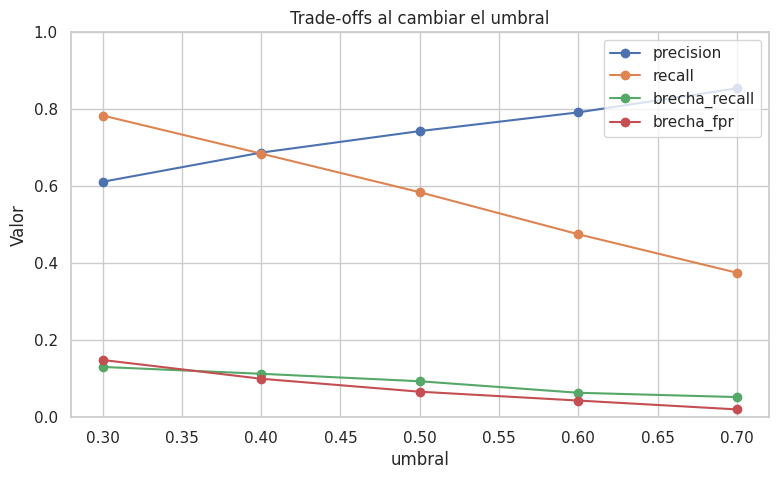

In [ ]:
filas_umbral = []
for umbral in [0.30, 0.40, 0.50, 0.60, 0.70]:
    pred_umbral = (proba_sin_sex >= umbral).astype(int)
    global_umbral = resumen_global(y_test, pred_umbral)
    grupo_umbral = metricas_por_grupo(y_test, pred_umbral, A_test)
    filas_umbral.append({
        "umbral": umbral,
        **global_umbral,
        "brecha_recall": (
            grupo_umbral["recall"].max() -
            grupo_umbral["recall"].min()
        ),
        "brecha_fpr": (
            grupo_umbral["fpr"].max() -
            grupo_umbral["fpr"].min()
        )
    })

resultados_umbral = pd.DataFrame(filas_umbral).set_index("umbral")
display(resultados_umbral.round(3))

resultados_umbral[
    ["precision", "recall", "brecha_recall", "brecha_fpr"]
].plot(marker="o", figsize=(9, 5))
plt.title("Trade-offs al cambiar el umbral")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.show()


### Antes de ejecutar: elegir y justificar un umbral

**Vocabulario:** `umbral_elegido` es una decisión humana guardada en una variable; puedes cambiar 0.40 y volver a ejecutar.

**¿Qué hace?** Muestra las métricas globales y por grupo correspondientes al valor seleccionado.

**¿Qué no hace?** No aprueba el modelo y no convierte una preferencia técnica en una decisión ética completa.

**¿Qué debes observar?** Qué métrica mejora, cuál empeora y a quién podría afectar el nuevo equilibrio.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


In [ ]:
# Cambia este valor y vuelve a ejecutar.
umbral_elegido = 0.40
pred_elegida = (proba_sin_sex >= umbral_elegido).astype(int)

print("Métricas globales:")
display(pd.Series(
    resumen_global(y_test, pred_elegida),
    name=f"umbral={umbral_elegido}"
).to_frame().round(3))
print("Métricas por grupo:")
display(metricas_por_grupo(y_test, pred_elegida, A_test).round(3))


Métricas globales:


,umbral=0.4
accuracy,0.850
balanced_accuracy,0.793
precision,0.687
recall,0.685
f1,0.686
tasa_seleccion,0.238


Métricas por grupo:


,soporte,positivos_reales,accuracy,precision,recall,fpr,fnr,tasa_seleccion
grupo,,,,,,,,
Female,4024,453,0.921,0.673,0.589,0.036,0.411,0.099
Male,8187,2469,0.815,0.690,0.702,0.136,0.298,0.307


### Antes de ejecutar: comparar tres versiones

**Vocabulario:** El modelo de referencia usa las variables preparadas del taller con umbral 0.50. El modelo modificado conserva ese entrenamiento y cambia el umbral.

**¿Qué hace?** Compara tu selección, el modelo de referencia y la versión con el umbral elegido usando las mismas métricas.

**¿Qué no hace?** No declara un ganador automático: cada columna combina rendimiento, errores, diferencias y complejidad.

**¿Qué debes observar?** Qué modelo lidera cada fila y si la mayor accuracy coincide con las menores brechas.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


In [ ]:
def resumen_para_comparar(y_true, y_pred, grupos):
    global_m = resumen_global(y_true, y_pred)
    tn_c, fp_c, fn_c, tp_c = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()
    grupos_m = metricas_por_grupo(y_true, y_pred, grupos)
    return {
        "Número de variables": np.nan,
        "Accuracy": global_m["accuracy"],
        "Precision": global_m["precision"],
        "Recall": global_m["recall"],
        "F1-score": global_m["f1"],
        "Falsos positivos": int(fp_c),
        "Falsos negativos": int(fn_c),
        "Brecha de recall": (
            grupos_m["recall"].max() - grupos_m["recall"].min()
        ),
        "Brecha de FPR": (
            grupos_m["fpr"].max() - grupos_m["fpr"].min()
        )
    }

participante_comp = resumen_para_comparar(
    y_test, predicciones_participante, A_test
)
participante_comp["Número de variables"] = len(variables_participante)

referencia_comp = resumen_para_comparar(
    y_test, pred_sin_sex, A_test
)
referencia_comp["Número de variables"] = X_test_sin.shape[1]

modificado_comp = resumen_para_comparar(
    y_test, pred_elegida, A_test
)
modificado_comp["Número de variables"] = X_test_sin.shape[1]

comparacion_tres_modelos = pd.DataFrame({
    "Tu modelo": participante_comp,
    "Referencia (umbral 0.50)": referencia_comp,
    f"Modificado (umbral {umbral_elegido:.2f})": modificado_comp
})
display(comparacion_tres_modelos.round(3))


,Tu modelo,Referencia (umbral 0.50),Modificado (umbral 0.40)
Número de variables,6.000,12.000,12.000
Accuracy,0.818,0.852,0.850
Precision,0.726,0.743,0.687
Recall,0.387,0.585,0.685
F1-score,0.505,0.654,0.686
Falsos positivos,427.000,590.000,910.000
Falsos negativos,1792.000,1214.000,921.000
Brecha de recall,0.014,0.094,0.113
Brecha de FPR,0.016,0.066,0.100


**Defiende tu umbral:**

- Elegí ...
- Mejoró ...
- Empeoró ...
- No podría aprobarlo todavía porque ...

**Pausa de auditoría 4:** compara el resultado nuevo con el umbral
0.50 y anota qué mejoró y qué empeoró.

### Compara las tres versiones

1. ¿Qué modelo obtuvo mayor accuracy?
2. ¿Cuál obtuvo mayor recall?
3. ¿Cuál produjo menos falsos positivos?
4. ¿Cuál mostró menores brechas entre grupos?
5. ¿El modelo con mayor accuracy fue también el más equilibrado?
6. ¿Cómo influyó tu selección de variables?
7. ¿Qué modelo recomendarías y bajo qué condiciones?


# 9. Interpretar el modelo sin inventar causalidad

Inspeccionaremos coeficientes de la regresión logística sin `sex`.
Coeficiente positivo significa asociación con mayor *log-odds* predicho,
manteniendo las demás columnas del modelo. **No significa causa,
importancia moral ni permiso de uso.**

Las numéricas fueron estandarizadas; las categorías están codificadas
frente al resto de columnas one-hot. La correlación entre atributos
puede cambiar los coeficientes.


### Antes de ejecutar: inspeccionar asociaciones aprendidas

**Vocabulario:** Un coeficiente es un peso aprendido; positivo aumenta la puntuación y negativo la reduce. Odds ratio no es lo mismo que probabilidad.

**¿Qué hace?** Ordena los coeficientes del modelo para ver asociaciones positivas y negativas fuertes.

**¿Qué no hace?** No descubre causas, no asigna mérito y no demuestra que una variable sea apropiada para decidir.

**¿Qué debes observar?** Si aparecen variables relacionadas con estructura familiar, ocupación o país y por qué podrían actuar como proxies.

No necesitas memorizar el código. Ejecuta la celda con el botón ▶ y
concentra tu atención en la pregunta que responde su resultado.


In [ ]:
nombres = modelo_sin_sex.named_steps["preparacion"].get_feature_names_out()
coeficientes = modelo_sin_sex.named_steps["modelo"].coef_[0]
tabla_coef = pd.DataFrame({
    "atributo_transformado": nombres,
    "coeficiente": coeficientes,
    "odds_ratio_aprox": np.exp(coeficientes)
}).sort_values("coeficiente")

print("Asociaciones negativas más grandes:")
display(tabla_coef.head(8).round(3))
print("Asociaciones positivas más grandes:")
display(tabla_coef.tail(8).sort_values("coeficiente", ascending=False).round(3))


Asociaciones negativas más grandes:


,atributo_transformado,coeficiente,odds_ratio_aprox
44,cat__occupation_Priv-house-serv,-1.529,0.217
64,cat__native-country_Columbia,-1.408,0.245
33,cat__marital-status_Never-married,-1.282,0.277
66,cat__native-country_Dominican-Republic,-0.985,0.374
52,cat__relationship_Other-relative,-0.929,0.395
95,cat__native-country_South,-0.925,0.397
35,cat__marital-status_Widowed,-0.906,0.404
40,cat__occupation_Farming-fishing,-0.901,0.406


Asociaciones positivas más grandes:


,atributo_transformado,coeficiente,odds_ratio_aprox
2,num__capital-gain,2.302,9.995
31,cat__marital-status_Married-civ-spouse,1.493,4.450
30,cat__marital-status_Married-AF-spouse,1.249,3.486
81,cat__native-country_Ireland,1.118,3.059
70,cat__native-country_France,0.937,2.553
61,cat__native-country_Cambodia,0.824,2.280
39,cat__occupation_Exec-managerial,0.768,2.155
1,num__education-num,0.760,2.137


**Pregunta:** el modelo no usa `sex`, pero una categoría de
`relationship` aparece entre los coeficientes fuertes. ¿Por qué esto
obliga a pensar en proxies y contexto?

**Tu respuesta:** ...


# 10. Decisión individual de auditoría

Completa tu ficha individual `FICHA_AUDITORIA.md` y toma una decisión
propia:

- aprobar;
- aprobar con condiciones;
- solicitar modificaciones;
- recopilar datos más adecuados;
- limitar a un contexto de bajo impacto;
- no implementar.

Usa esta estructura:

> Recomendamos ______ porque encontramos ______. La evidencia principal
> fue ______. Antes de implementarlo debería ______.

Tu argumento debe incluir un número, una consecuencia y una limitación.

Incluye también una reflexión sobre tu primera versión:

- ¿Qué variables utilizaste?
- ¿Cómo se comparó con el modelo de referencia?
- ¿Qué decisión de selección tuvo mayor impacto?
- ¿Fue mejor en alguna métrica y peor en alguna medida por grupos?
- ¿Cambiarías tu selección inicial?
- ¿Qué aprendiste sobre la relación entre datos, rendimiento y sesgo?


## Tu recomendación

**Hallazgo:** ...

**Evidencia:** ...

**Riesgo/personas afectadas:** ...

**Decisión y controles:** ...

**Lo que aún no sabemos:** ...

**Mi selección inicial y comparación con la referencia:** ...

**Lo que cambiaría después del taller:** ...


# Cierre: cinco ideas que deben quedar

1. Un dataset adecuado depende de la decisión y la población, no solo de
   cuántas filas contiene.
2. Limpiar es tomar decisiones; documenta qué cambia y para quién.
3. Accuracy puede ocultar desbalance, tipos de error y diferencias entre
   grupos.
4. Quitar una variable sensible o cambiar un umbral no garantiza equidad.
5. Una auditoría responsable une métricas, contexto, consecuencias,
   incertidumbre, gobernanza y capacidad de reparación.

**Salida:** escribe una acción que aplicarás en tu próximo proyecto de
datos.
